Name: Ronish Shrestha

Group: L6CG6

Student Number: 2408383

# Implementation of MCP Neuron for AND and OR Function.

In [1]:
def MCP_Neurons_AND(X1, X2, T):
    # Make sure both inputs have same length
    assert len(X1) == len(X2)

    state_neuron = []  # This will store final outputs (0 or 1)

    # Loop through each pair of inputs
    for i in range(len(X1)):
        summation = X1[i] + X2[i]  # Add inputs

        # Apply threshold condition
        if summation >= T:
            state_neuron.append(1)  # Output 1 if condition satisfied
        else:
            state_neuron.append(0)  # Otherwise output 0

    return state_neuron

In [2]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [3]:
def MCP_Neurons_OR(X1, X2, T):
    # Check both inputs have same size
    assert len(X1) == len(X2)

    state_neuron = []  # Store outputs

    # Loop through inputs
    for i in range(len(X1)):
        summation = X1[i] + X2[i]  # Add values

        # Apply OR logic using threshold
        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [4]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


3.2.1 Answer the Following Question:

Question - 1: List out all the limitations of MCP - Neurons.

*   No learning capability (weights are fixed manually)
*   Cannot handle non-linear problems (like XOR)
*   Only works with binary inputs/outputs
*   No weight importance (all inputs treated equally)
*   No adaptability or optimization
*   Cannot generalize from data

Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.

No, single MCP neuron cannot solve XOR.




*   XOR is not linearly separable
*   MCP uses simple threshold logic → fails

We would need:


*   Multiple neurons (hidden layer)
*   OR use perceptron/network


# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [5]:
from google.colab import files

uploaded = files.upload()

Saving mnist_0_and_1.csv to mnist_0_and_1.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Load the dataset
df_0_1 = pd.read_csv("/content/mnist_0_and_1.csv")

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Viewing the Dataset.

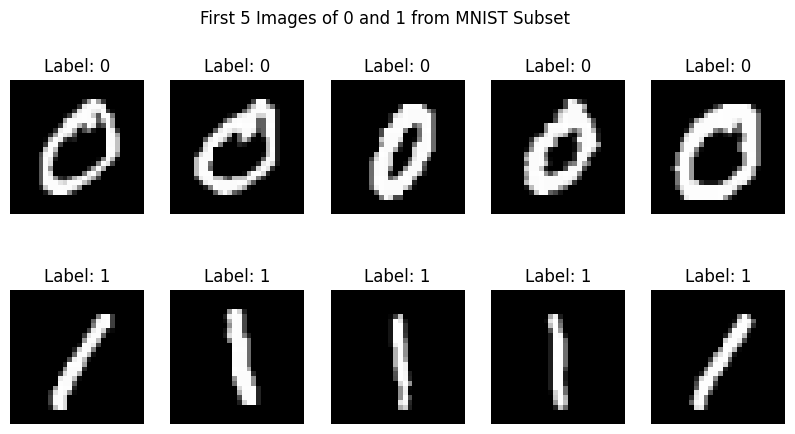

In [7]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [8]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

Question - 3: What does the weights array represent in this context?


*   The weights array represents the importance of each input feature in making the model’s prediction.



Question - 4: Why are we initializing the weights to zero? What effect could this have on the training process?

*   Initializing weights to zero is simple and ensures all features start equally. For a single perceptron it works fine, but it can slightly slow down convergence compared to small random values.

## Step - 3 - Make a Decision function:

In [9]:
def decision_function(X, weights, bias):
    # Calculate weighted sum for all samples
    predictions = np.dot(X, weights) + bias

    # Apply step function (activation)
    # If value >= 0 → 1, else → 0
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [10]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    # Loop over epochs (iterations)
    for epoch in range(epochs):
        correct = 0  # Count correct predictions

        # Loop through each training example
        for i in range(len(X)):

            # Calculate weighted sum
            output = np.dot(X[i], weights) + bias

            # Apply step function
            y_pred = 1 if output >= 0 else 0

            # If prediction is wrong → update weights
            if y_pred != y[i]:
                # Update weights
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]

                # Update bias
                bias = bias + learning_rate * (y[i] - y_pred)
            else:
                correct += 1  # Count correct prediction

        # Calculate accuracy for this epoch
        accuracy = correct / len(X)
        print(f"Epoch {epoch+1}: Accuracy = {accuracy:.4f}")

    return weights, bias, accuracy

Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?  

*   output = np.dot(X[i], weights) + bias calculates the linear combination of inputs and weights, giving the model’s raw prediction (logit) before activation.

Question - 6: What happens when the prediction is wrong? How are the weights and
bias updated?

*   Final accuracy shows how well the model learned to separate the two classes. For 0 vs 1 we expect nearly 100% (highly linearly separable). For 3 vs 5 we expect around 98% because these digits are more similar and not perfectly linearly separable.

Question - 7:Why is the final accuracy important, and what do you expect it to be?

*   Final accuracy shows how well the model learned to separate the two classes. For 0 vs 1 we expect nearly 100% (highly linearly separable). For 3 vs 5 we expect around 98% because these digits are more similar and not perfectly linearly separable.

## Training the Perceptron

In [11]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Epoch 1: Accuracy = 0.9967
Epoch 2: Accuracy = 0.9982
Epoch 3: Accuracy = 0.9987
Epoch 4: Accuracy = 0.9987
Epoch 5: Accuracy = 0.9990
Epoch 6: Accuracy = 0.9993
Epoch 7: Accuracy = 0.9998
Epoch 8: Accuracy = 0.9995
Epoch 9: Accuracy = 0.9989
Epoch 10: Accuracy = 0.9992
Epoch 11: Accuracy = 0.9995
Epoch 12: Accuracy = 0.9998
Epoch 13: Accuracy = 1.0000
Epoch 14: Accuracy = 1.0000
Epoch 15: Accuracy = 1.0000
Epoch 16: Accuracy = 1.0000
Epoch 17: Accuracy = 1.0000
Epoch 18: Accuracy = 1.0000
Epoch 19: Accuracy = 1.0000
Epoch 20: Accuracy = 1.0000
Epoch 21: Accuracy = 1.0000
Epoch 22: Accuracy = 1.0000
Epoch 23: Accuracy = 1.0000
Epoch 24: Accuracy = 1.0000
Epoch 25: Accuracy = 1.0000
Epoch 26: Accuracy = 1.0000
Epoch 27: Accuracy = 1.0000
Epoch 28: Accuracy = 1.0000
Epoch 29: Accuracy = 1.0000
Epoch 30: Accuracy = 1.0000
Epoch 31: Accuracy = 1.0000
Epoch 32: Accuracy = 1.0000
Epoch 33: Accuracy = 1.0000
Epoch 34: Accuracy = 1.0000
Epoch 35: Accuracy = 1.0000
Epoch 36: Accuracy = 1.0000
E

## Step 5: Visualize Misclassified Images

In [12]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Question - 8: What does misclassified idx store, and how is it used in this code?  

*   misclassified_idx stores the indices of samples the model predicted incorrectly, used to check or analyze errors.

Question - 9: How do you interpret the result if the output is ”All images were correctly classified!”?
*   All images were correctly classified!” means the model predicted every sample correctly, showing perfect accuracy on that dataset

For 3 nd 5.

In [13]:
from google.colab import files

uploaded = files.upload()

Saving mnist_3_and_5.csv to mnist_3_and_5.csv


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Load dataset
df_3_5 = pd.read_csv("/content/mnist_3_and_5.csv")

# Separate features and labels
X = df_3_5.drop(columns=["label"]).values
y = df_3_5["label"].values

# Convert labels: 3 → 0, 5 → 1
y = np.where(y == 3, 0, 1)

# Check shapes
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


In [15]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])
bias = 0

learning_rate = 0.1
epochs = 100

In [16]:
# Decision function
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias  # weighted sum
    return np.where(predictions >= 0, 1, 0)  # step function

In [17]:
# Train perceptron
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            # Correct logic
            if y_pred != y[i]:
                weights += learning_rate * (y[i] - y_pred) * X[i]
                bias += learning_rate * (y[i] - y_pred)
            else:
                correct += 1

        accuracy = correct / len(X)
        print(f"Epoch {epoch+1}: Accuracy = {accuracy:.4f}")

    return weights, bias, accuracy

In [18]:
# Train model
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy:", accuracy)

Epoch 1: Accuracy = 0.9157
Epoch 2: Accuracy = 0.9372
Epoch 3: Accuracy = 0.9416
Epoch 4: Accuracy = 0.9475
Epoch 5: Accuracy = 0.9489
Epoch 6: Accuracy = 0.9504
Epoch 7: Accuracy = 0.9599
Epoch 8: Accuracy = 0.9559
Epoch 9: Accuracy = 0.9540
Epoch 10: Accuracy = 0.9566
Epoch 11: Accuracy = 0.9599
Epoch 12: Accuracy = 0.9580
Epoch 13: Accuracy = 0.9657
Epoch 14: Accuracy = 0.9602
Epoch 15: Accuracy = 0.9635
Epoch 16: Accuracy = 0.9657
Epoch 17: Accuracy = 0.9606
Epoch 18: Accuracy = 0.9624
Epoch 19: Accuracy = 0.9610
Epoch 20: Accuracy = 0.9661
Epoch 21: Accuracy = 0.9701
Epoch 22: Accuracy = 0.9690
Epoch 23: Accuracy = 0.9730
Epoch 24: Accuracy = 0.9683
Epoch 25: Accuracy = 0.9650
Epoch 26: Accuracy = 0.9715
Epoch 27: Accuracy = 0.9734
Epoch 28: Accuracy = 0.9694
Epoch 29: Accuracy = 0.9715
Epoch 30: Accuracy = 0.9726
Epoch 31: Accuracy = 0.9668
Epoch 32: Accuracy = 0.9715
Epoch 33: Accuracy = 0.9694
Epoch 34: Accuracy = 0.9741
Epoch 35: Accuracy = 0.9741
Epoch 36: Accuracy = 0.9686
E

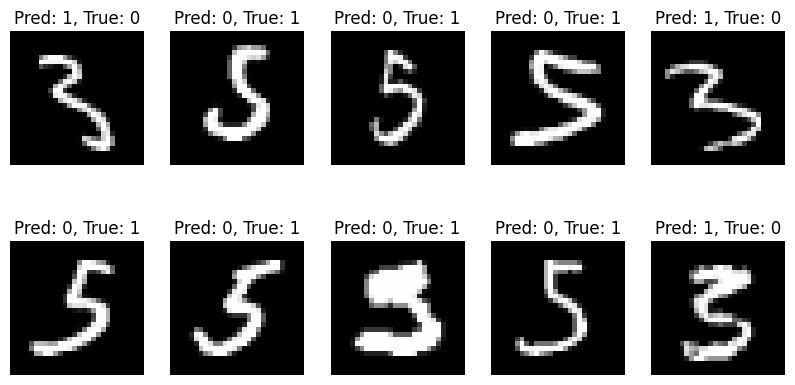

In [19]:
# Predict all values
y_pred = decision_function(X, weights, bias)

# Find wrong predictions
misclassified_idx = np.where(y_pred != y)[0]

# Show misclassified images
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10,5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28,28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.show()
else:
    print("All images were correctly classified!")

Conclusion:

The perceptron achieved ~98.6% accuracy, which is strong but not 100% because digits 3 and 5 are not perfectly linearly separable.